# [LAB-10] 로지스틱회귀ㅣ4-1-혼동행렬의 이해(실습코드).ipynb

## #01. 준비작업 

### 1. 라이브러리 참조

In [1]:
# 라이브러리 기본 참조 
from jussam import load_data
from helpers import *
from pandas import DataFrame

import numpy as np

# 분류 성능 평가를 위한 참조 
from sklearn.metrics import confusion_matrix

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 
직전 단원과 동일한 데이터에 대해 전처리가 완료된 데이터를 준비한다. 

In [2]:
origin = load_data('pima_indians_diabetes_preprocessed')
origin.head()

📚 피마 인디언 당뇨병 데이터셋에 대한 전처리 버전 - 결측치 처리, 이상치 처리, 라벨링 (출처: 자체 작업)


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.000,72.000,33.600,0.627,50,1
1,1,85.000,66.000,26.600,0.351,31,0
2,8,183.000,64.000,23.300,0.672,32,1
3,1,89.000,66.000,28.100,0.167,21,0
4,0,137.000,40.000,43.100,2.288,33,1


### 3. 로지스틱 회귀모델 적합 

In [3]:
fit = my_logit.auto_logit(origin, 'Outcome', plot=False)    

#### -> 모형적합도

**Note. n=724.LL = -336.431, LL-Null = -465.969, LLR x^2 (6) = 259.076, p < 0.001, Pseudo R^2 = 0.278**

Outcome를 종속변수로, Pregnancies, Glucose, BloodPressure, BMI, DiabetesPedigreeFunction, Age(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR x^2 (6)=259.076, p < 0.001, Pseudo R^2 = 0.278.

즉, 모형의 유사결정계수는 0.278로 매우 우수한적합 수준을 보였다.

> Pseudo R^2는 선형회귀의 R^2처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다

#### -> 독립변수 보고

,종속변수,독립변수,B,베타std,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,DiabetesPedigreeFunction,0.961,0.319,0.306,3.135,0.002,2.613,1.433,4.764,0.959,1.043
1,Outcome,Pregnancies,0.118,0.396,0.033,3.527,0.000,1.125,1.054,1.201,0.687,1.455
2,Outcome,BMI,0.091,0.626,0.016,5.777,0.000,1.095,1.062,1.130,0.860,1.162
3,Outcome,Glucose,0.035,1.082,0.004,9.763,0.000,1.036,1.029,1.043,0.865,1.156
4,Outcome,Age,0.017,0.199,0.010,1.723,0.085,1.017,0.998,1.037,0.615,1.626
5,Outcome,BloodPressure,-0.009,-0.110,0.009,-1.035,0.301,0.991,0.975,1.008,0.804,1.243


- **Pregnancies**의 회귀계수는 **B = 0.1179**, 오즈비는 **OR=1.1251**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다(**z = 3.53**, **p < .001**)즉, **Pregnancies**가 1 증가할때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **12.5% 증가** 하는 것으로 해석된다.
- **Glucose**의 회귀계수는 **B = 0.0352**, 오즈비는 **OR=1.0358**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다(**z = 9.76**, **p < .001**)즉, **Glucose**가 1 증가할때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.6% 증가** 하는 것으로 해석된다.
- **BloodPressure**의 회귀계수는 **B = -0.0089**, 오즈비는 **OR=0.9911**로 나타났으며, 이는 **Outcome**에 유의하지 않은 요인임을 의미한다(**z = -1.03**, **p=.301**)즉, **BloodPressure**가 1 증가할때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **0.9% 감소** 하는 것으로 해석된다.
- **BMI**의 회귀계수는 **B = 0.0909**, 오즈비는 **OR=1.0952**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다(**z = 5.78**, **p < .001**)즉, **BMI**가 1 증가할때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **9.5% 증가** 하는 것으로 해석된다.
- **DiabetesPedigreeFunction**의 회귀계수는 **B = 0.9605**, 오즈비는 **OR=2.613**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다(**z = 3.13**, **p=.002**)즉, **DiabetesPedigreeFunction**가 1 증가할때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **161.3% 증가** 하는 것으로 해석된다.
- **Age**의 회귀계수는 **B = 0.0169**, 오즈비는 **OR=1.0171**로 나타났으며, 이는 **Outcome**에 유의하지 않은 요인임을 의미한다(**z = 1.72**, **p=.085**)즉, **Age**가 1 증가할때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **1.7% 증가** 하는 것으로 해석된다.

> 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된)범주' 대비 값이다

## #02. 혼동행렬(Confusion Matrix)  

### 1. 혼동행렬 구성 1단계 - 실제 정답 꺼내기 
적합된 모형 객체 안에는 학습에 사용한 실제 종속변수 값이 들어있다. 

In [4]:
# endog = endogenous variable, 즉 종속변수라는 뜻

In [5]:
# 실제 당뇨 여부(0/1)
y_true = np.asarray(fit.model.endog).astype(int)    

# 상위 20개만 출력 
y_true[:20]

array([1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1])

### 2. 혼동행렬 구성 2단계 - 모형이 예측한 확률 꺼내기 
로지스틱 회귀의 예측값은 0이나 1이 아니라, "당뇨일 확률(0~1 사이의 값)"이다. \
그래서 곧바로 정답(종속변수 -> 0 혹은 1)과 비교할 수 없다. 

In [6]:
# 각 사람이 당뇨(1)일 예측 확률 
proba = np.asanyarray(fit.predict())

# 상위 20개만 소수점 3자리로 반올림하여 출력
proba[:20].round(3)

array([0.693, 0.041, 0.761, 0.038, 0.898, 0.128, 0.057, 0.803, 0.209,
       0.883, 0.77 , 0.801, 0.646, 0.416, 0.172, 0.307, 0.227, 0.437,
       0.3  , 0.937])

### 3. 혼동행렬 구성 3단계 - 확률을 0/1로 자르기 
확률을 범주로 바꾸려면 자르는 기준(임계값, threshold)이 필요하다\
관례적으로 0.5를 쓴다. 즉 50%를 넘으면 당뇨(1)로 본다\
임계값은 정해진 값이 아니라 분석자가 고르는 값이다.(뒤에서 바꿔 본다)

In [7]:
# 임계값 0.5로 이진화 
y_pred = (proba>0.5).astype(int)

# 상위 20개만 출력 
y_pred[:20]

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1])

### 현재 모형의 혼동행렬
statsmodels만으로 이 네칸을 구하기는 번거롭기 때문에 머신러닝 라이브러리인 sklearn의 함수를 미리 빌려쓴다.\
실제값과 예측범주를 confusion_martix()에 넣으면 2x2표가 나온다  

In [8]:
cm = confusion_matrix(y_true, y_pred)

cmdf = DataFrame(cm, 
                 index=["실제 0 (정상)", "실제 1 (당뇨)"], 
                        columns=["예측 0(정상)", "예측 1 (당뇨)"])  

cmdf

,예측 0(정상),예측 1 (당뇨)
실제 0 (정상),420,55
실제 1 (당뇨),107,142


### 5. 각 지표를 개별 추출하기 

In [9]:
# 네 칸을 TN/ FP/ FN/ TP로 분해 (순서가 정해져 있다)
tn, fp, fn, tp = cm.ravel()

print(f"TN(정상인을 정상으로 맞힘): {tn}")
print(f"FP(정상인을 당뇨로 헛짚음): {fp}")
print(f"FN(당뇨 환자를 놓침): {fn}")
print(f"TP(당뇨 환자를 맞힘): {tp}")

TN(정상인을 정상으로 맞힘): 420
FP(정상인을 당뇨로 헛짚음): 55
FN(당뇨 환자를 놓침): 107
TP(당뇨 환자를 맞힘): 142


### 혼동 행렬 히트맵

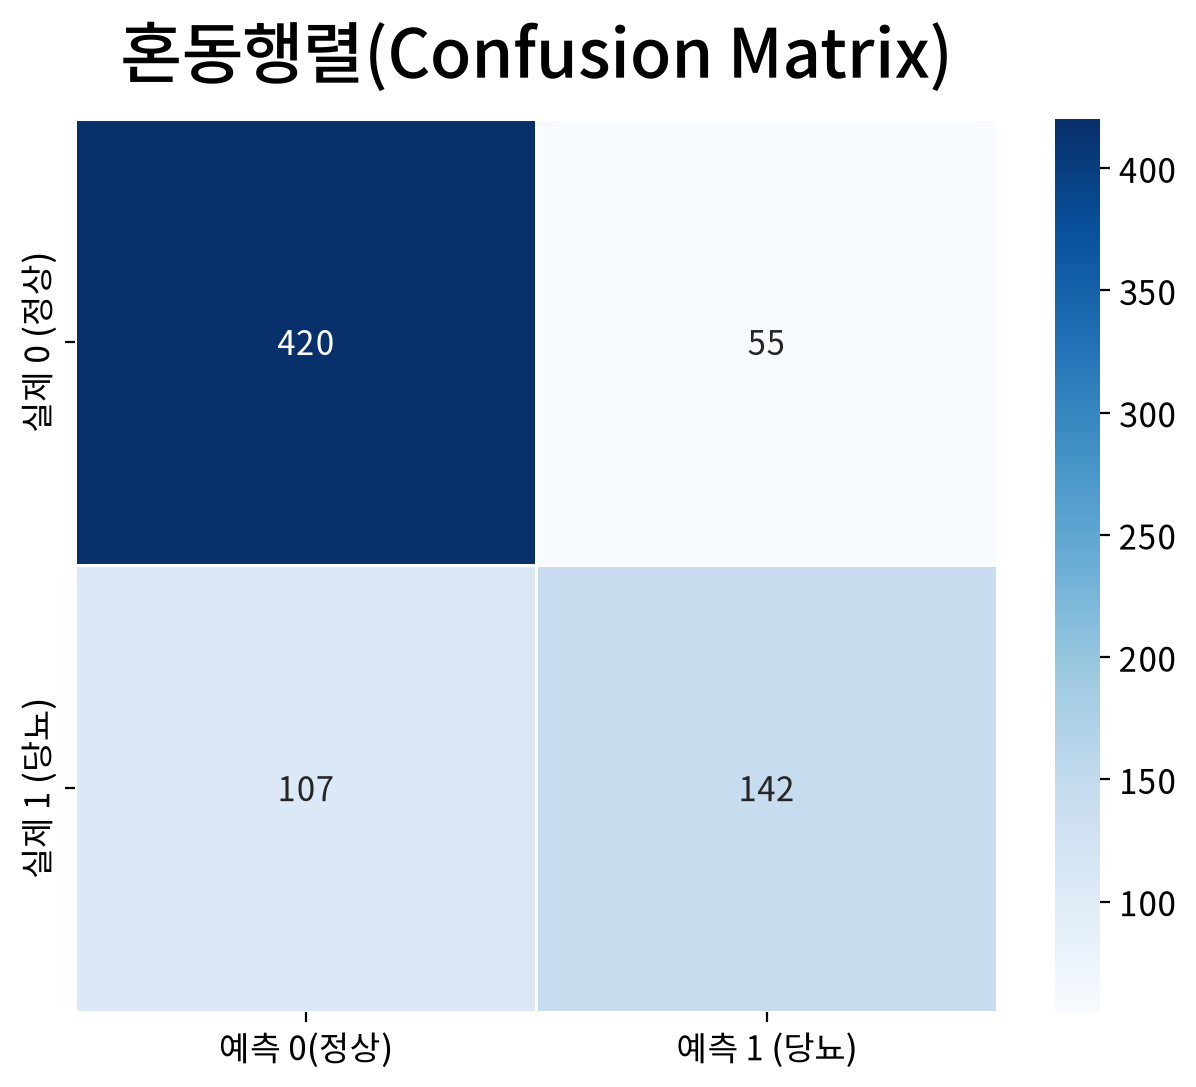

In [10]:
my_plot.heatmap(data=cmdf, annot=True, fmt="d", palette='Blues', 
                title="혼동행렬(Confusion Matrix)", width=640, height=560)

### 4-2 분류 성능 평가지표 

In [11]:
# 정확도 Accuracy
# 정밀도 Precision 
# 재현율 Recall 
# 위양성률 Fallout, FPR
# 특이성 Specificity, TNR
# F1 정밀도와 재현율의 조화평균 
# ROC 
# AUC 
# 오즈 일어날 확률/일어나지않을확률
# 오즈비 두집단의 오즈끼리 나눈값(앞에서는 회귀계수를 지수변환해 구랬고, 여기서는 혼동행렬로 구한다.)
# 진단 오즈비 Diagnostic Odds Radio 혼동행렬을 통해 모형의 판정과 실제 상태가 얼마나 강하게 연결되는지 계산가능



## #01. 준비 작업 

In [12]:
# 라이브러리 기본 참조 
from jussam import load_data
from helpers import * 
from pandas import DataFrame

import numpy as np

# 분류 성능 평가를 위한 참조 
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score 

### 2. 데이터 가져오기 + 분류 모델 적합 
직전 단원과 동일한 데이터에 대해 전처리가 완료된 데이터를 준비한다. 

In [13]:
origin = load_data('pima_indians_diabetes_preprocessed')    
fit = my_logit.auto_logit(origin, 'Outcome', plot=False, report=False)

📚 피마 인디언 당뇨병 데이터셋에 대한 전처리 버전 - 결측치 처리, 이상치 처리, 라벨링 (출처: 자체 작업)



### 3. 혼동행렬 지표 얻기 

In [14]:
y_true = np.asanyarray(fit.model.endog).astype(int) # 실제 당뇨 여부(0/1)
proba = np.asarray(fit.predict()) # 당뇨(1)일 예측 확률
y_pred = (proba>0.5).astype(int) # 임계값 0.5로 이진화 
cm = confusion_matrix(y_true, y_pred) # 혼동행렬 배열

# 네 칸을 TN/ FP / FN / TP 로 분해 (순서가 정해져 있다)
tn, fp, fn, tp = cm.ravel()

print(f"TN(정상인을 정상으로 맞힘): {tn}")
print(f"FP(정상인을 당뇨로 헛짚음): {fp}")
print(f"FN(당뇨 환자를 놓침): {fn}")
print(f"TP(당뇨 환자를 맞힘): {tp}")

TN(정상인을 정상으로 맞힘): 420
FP(정상인을 당뇨로 헛짚음): 55
FN(당뇨 환자를 놓침): 107
TP(당뇨 환자를 맞힘): 142


## #02. 정확도 (Accuracy)

### 1. 직접 구하기 

In [15]:
(tn +tp) / (tn + fp+ fn+ tp)

np.float64(0.7762430939226519)

### 2. 함수로 구하기 

In [16]:
acc = accuracy_score(y_true, y_pred)
acc

0.7762430939226519

### 3. 정확도의 함정(1) - 정답의 구성 비율 확인 

In [17]:
# 종속변수의 값별 개수 
count = origin["Outcome"].value_counts()

# 종속변수의 값별 비율
ratio = origin["Outcome"].value_counts(normalize=True)

DataFrame({"인원수": count, "비율":ratio})

,인원수,비율
Outcome,,
0,475,0.656
1,249,0.344


### 4. 정확도의 함정(2) - 무조건 정상(0)이라고만 답하는 게으른 모형의 정확도 

In [18]:
# 아무것도 계산하지 않고 무조건 '정상()'이라고만 답하는 모형 
# --> 실제 정답의 길이만큼 0으로 채워진 배열을 만들어서 평가 
y_lazy = np.zeros(len(y_true), dtype=int)   

# 실제 정답과 모든 예측값이 0으로 채워진 배열에 대해 정확도 산출 
lazy_acc = accuracy_score(y_true, y_lazy)
print(f"'무조건 정상' 모형의 정확도 : {lazy_acc:.1%}")

'무조건 정상' 모형의 정확도 : 65.6%


## #03. 정밀도 (Precision) 와 재현율(Recall)

### 1. 직접 구하기 

In [19]:
pre = tp/ (tp+fp)
recall = tp/ (tp+fn)
print(f"정밀도(Precision) = TP/(TP+FP) = {pre:.4f}")
print(f"재현율(Recall) = TP/(TP+FN) = {recall:.4f}")

정밀도(Precision) = TP/(TP+FP) = 0.7208
재현율(Recall) = TP/(TP+FN) = 0.5703


### 2. 함수로 구하기 

In [20]:
# 직접 계산과 함수 계산이 같은지 확인 
pre = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

print(f"정밀도(Precision) = {pre:.4f}")
print(f"재현율(Recall) = {recall:.4f}")

정밀도(Precision) = 0.7208
재현율(Recall) = 0.5703


### 직접 계산하기 

In [21]:
fpr = fp / (fp+tn)  # 위양성률
tnr = 1-fpr # 특이성 

print(f"위양성률(FPR) = FP/(FP+TN) = {fp}/{fp+tn} = {fpr:.4f}")
print(f"특이성(TNR) = TN/(TN+FP) = {tn}/{tn+fp} = {tnr:.4f}")

위양성률(FPR) = FP/(FP+TN) = 55/475 = 0.1158
특이성(TNR) = TN/(TN+FP) = 420/475 = 0.8842


## #05. F1 점수 

### 1. 직접 계산 

In [22]:
f1 = (2*tp)/(2*tp + fp+ fn)
print(f"직접 계산: {f1:.4f}")

직접 계산: 0.6368


### 2. 함수 계산 

In [23]:
f1 = f1_score(y_true, y_pred)
print(f"함수계산: {f1:.4f}")

함수계산: 0.6368


## # 목적에 따른 임계값 조절 
### 임계값을 움직이면 벌어지는 일 

## #06. ROC 곡선과 AUC

### 1. 임계값에 따른 지표 변화 실험 

In [24]:
rows = []

for t in [0.3, 0.4, 0.5, 0.6, 0.7]: # 임계값을 0.3~0.7로 바꿔가며 관찰 
    p = (proba>t).astype(int) # 임계값 t로 이진화 
    rows.append({
        "임계값":t, 
        "정확도":accuracy_score(y_true, p), 
        "정밀도":precision_score(y_true, p), 
        "재현율":recall_score(y_true, p), 
        "F1":f1_score(y_true, p), 
        "놓친 환자수(FN)": confusion_matrix(y_true, p).ravel()[2], 
    })

display(DataFrame(rows).round(3))

,임계값,정확도,정밀도,재현율,F1,놓친 환자수(FN)
0,0.300,0.749,0.604,0.783,0.682,54
1,0.400,0.769,0.665,0.663,0.664,84
2,0.500,0.776,0.721,0.570,0.637,107
3,0.600,0.782,0.783,0.506,0.615,123
4,0.700,0.754,0.803,0.378,0.514,155


In [25]:
# 트레이드 오프 
# 정밀도와 재현율이 정확히 반대로 움직인다.

### 2. 임계값에 따른 FPR, TPR 좌표 얻기 

In [26]:
roc_fpr, roc_tpr, thresholds = roc_curve(y_true, proba)

print(f"계산된 임계값 개수: {len(thresholds)}개")
df = DataFrame({"임계값":thresholds, "FPR":roc_fpr, "TPR(재현율)":roc_tpr})
df.head()

계산된 임계값 개수: 227개


,임계값,FPR,TPR(재현율)
0,inf,0.000,0.000
1,0.992,0.000,0.004
2,0.981,0.002,0.004
3,0.967,0.002,0.012
4,0.962,0.004,0.012


### 3. ROC 곡선 시각화 

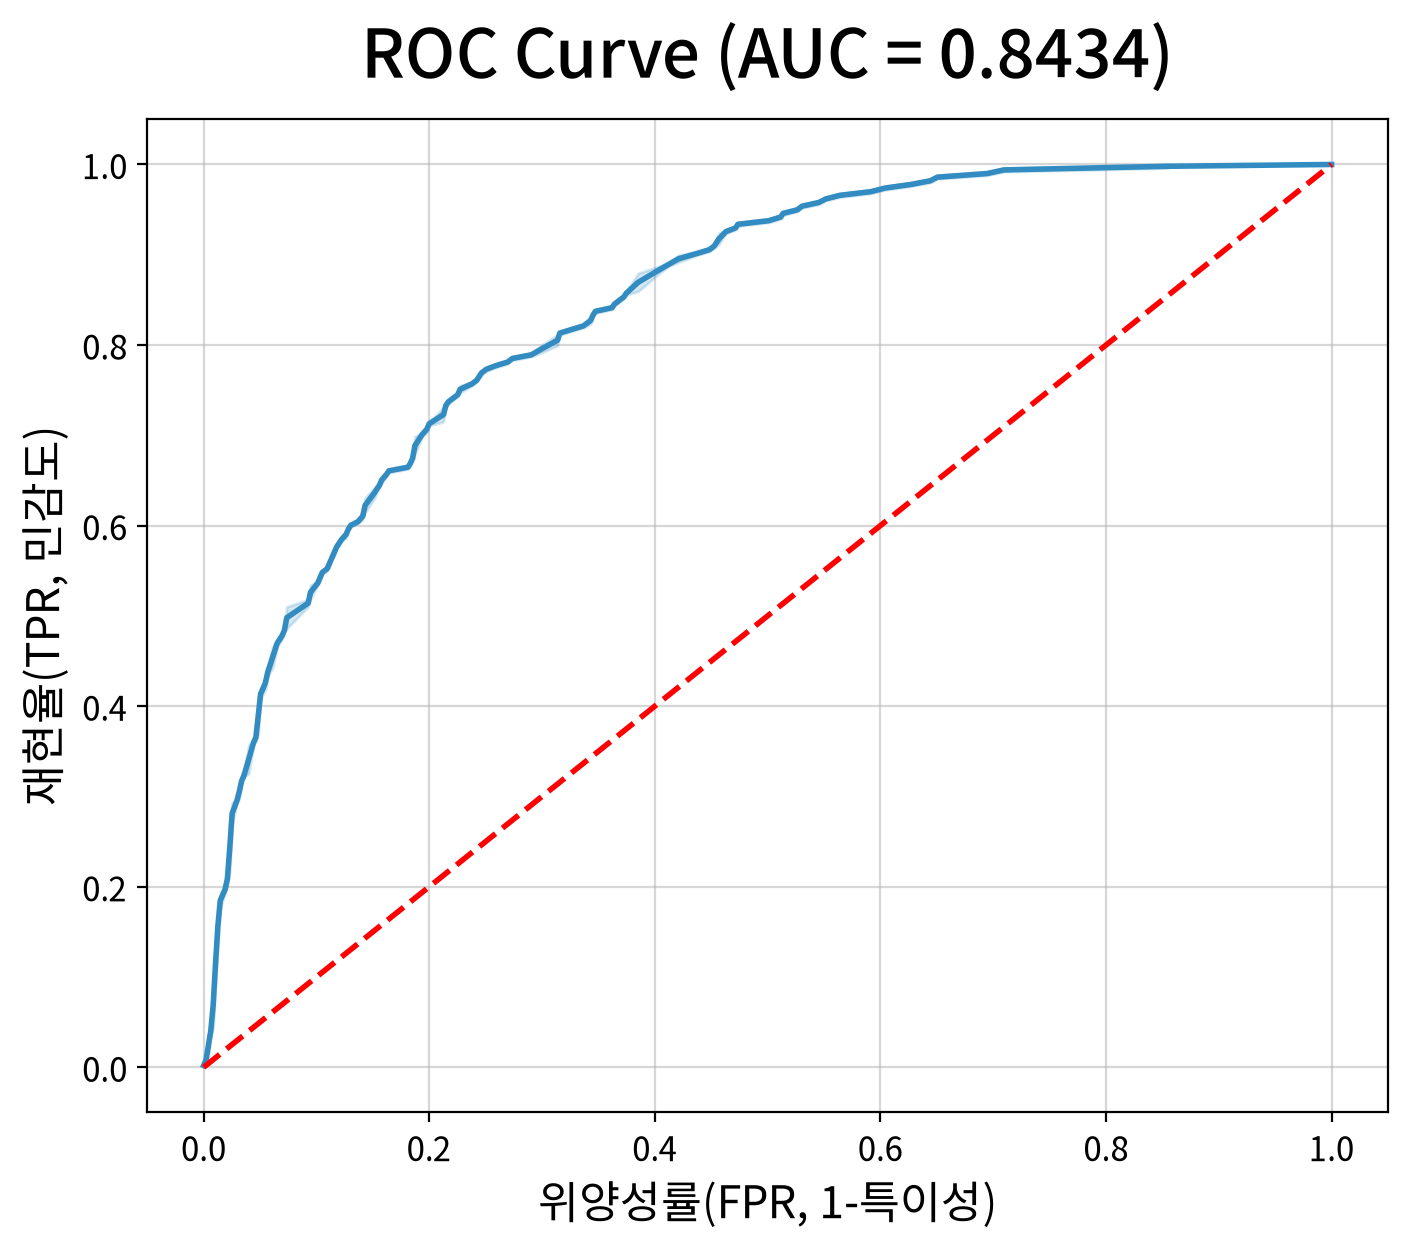

In [27]:
# ROC 곡선 아래 면적 (AUC, Area Under Curve) 계산 
auc = roc_auc_score(y_true, proba)

# 그래프 초기화 
fig, ax = my_plot.init(width=720, height=640, 
                       title=f"ROC Curve (AUC = {auc:.4f})", 
                       xlabel="위양성률(FPR, 1-특이성)", 
                       ylabel="재현율(TPR, 민감도)")

# ROC 곡선 
my_plot.lineplot(x=roc_fpr, y=roc_tpr, color="#328CC1", ax=ax)

# 무작위로 찍었을 때의 기준선(대각선)
my_plot.lineplot(x=[0,1], y=[0,1], color="red", linestyle="--", ax=ax)

# 그래프 표시 
my_plot.show()

## #06. 혼동 행렬로 보는 오즈비 

### 1. 진단 오즈비 

In [28]:
odds_ratio = (tp*tn) / (fp*fn)

print(f"진단 오즈비 = (TP x TN) / (FP x FN)"
      f" = ({tp} x {tn} ) / ({fp} x {fn})"
      f" = {odds_ratio:.4f}")

진단 오즈비 = (TP x TN) / (FP x FN) = (142 x 420 ) / (55 x 107) = 10.1342


In [29]:
# 1단계: 혼동행렬 자체부터 뭉개지 않게
# TN/FP/FN/TP 네 칸이 뭘 의미하는지 "실제-예측" 조합으로 즉시 말할 수 있어야 함. 예: FN = "실제 당뇨인데 정상이라고 예측함(놓친 환자)". 이게 안 되면 뒤에 나오는 정밀도/재현율 공식은 다 암기일 뿐, 이해가 아님.
# cm.ravel()이 항상 [TN, FP, FN, TP] 순서라는 것도 "왜 이 순서인지"까지 (2x2 배열을 flatten하면 row-major 순서라서) 설명 가능해야 함.
# 2단계: 지표 4개 — 공식보다 "언제 쓰는지"가 핵심

# 이 노트북 자체가 이미 좋은 예시를 줬어 (게으른 모형 정확도 함정). 복습 체크리스트:

# 정확도의 함정: 클래스 불균형일 때 왜 무의미해지는지, 숫자로(예: 무조건 0 찍어도 65% 나옴) 설명 가능한가
# 정밀도 vs 재현율: "이걸 낮추면 저게 올라간다"는 트레이드오프를 암 진단(재현율 중요) vs 스팸 필터(정밀도 중요) 같은 실제 예시로 바꿔 말할 수 있는가
# F1: 왜 산술평균이 아니라 조화평균인지 (극단값에 민감하게 만들어서 둘 다 어느 정도 balance 잡도록)
# 임계값 조절 실험 (0.3~0.7 loop): "임계값 낮추면 재현율↑ 정밀도↓" 방향을 표 없이도 즉석에서 말할 수 있는가
# 3단계: ROC/AUC — 여기가 젤 헷갈리는 구간
# FPR, TPR이 뭔지 혼동행렬 용어로 재정의 가능한가 (TPR=재현율, FPR=1-특이성)
# AUC=0.5가 왜 "랜덤 찍기"랑 같은지 (대각선 그래프 의미)
# roc_curve()가 리턴하는 thresholds 배열이 왜 원본 확률값 개수보다 적은지 (실제로 예측값이 바뀌는 지점만 뽑아내서)
# 진짜 아는 거 vs 아는 척의 기준

# 넌 이미 본인 방법론(블랭크페이지 복기 + 3-pass)이 있으니까 그대로 적용하면 돼. 구체적으로 이 노트북 기준으로는:

# 코드 없이 origin 데이터만 주어졌을 때 "혼동행렬 → 4개 지표 → ROC/AUC"까지 순서대로 손코딩 가능한가
# 왜 proba > 0.5로 자르는지, 이 임계값을 바꾸면 실무에서 어떤 의사결정 문제인지 말로 설명 가능한가 (이게 사실 면접에서 제일 많이 물어봄 — "재현율과 정밀도 중 뭐가 더 중요한 상황인지 예시 들어봐라")
# 오즈비까지 나온 김에: 이게 로지스틱 회귀 계수 해석(승산비)과 연결된다는 것도 짚고 넘어가면 좋음

## #01. 준비작업 

### 1. 라이브러리 참조 

In [30]:
# 라이브러리 기본 참조 
from jussam import load_data
from helpers import * 

### 2. 데이터 가져오기 + 분류모델 적합 

In [31]:
origin = load_data('pima_indians_diabetes_preprocessed')
fit = my_logit.auto_logit(origin, 'Outcome', plot=False, report=False)

📚 피마 인디언 당뇨병 데이터셋에 대한 전처리 버전 - 결측치 처리, 이상치 처리, 라벨링 (출처: 자체 작업)



## #02. 모듈화 기능 확인 

### 1. 혼동행렬 시각화 

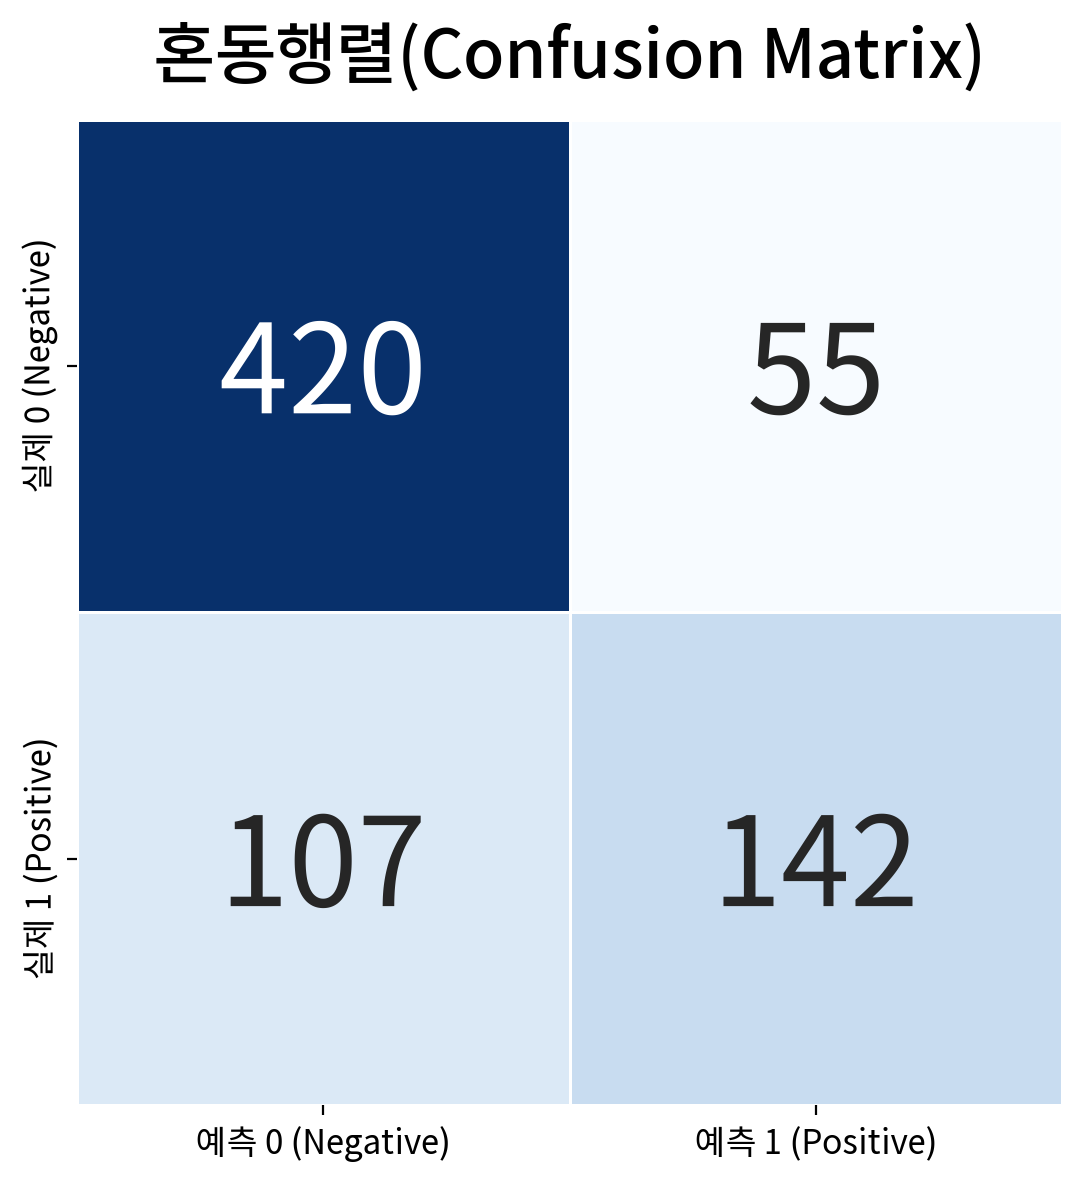

In [32]:
my_logit.plot_confusion(fit)

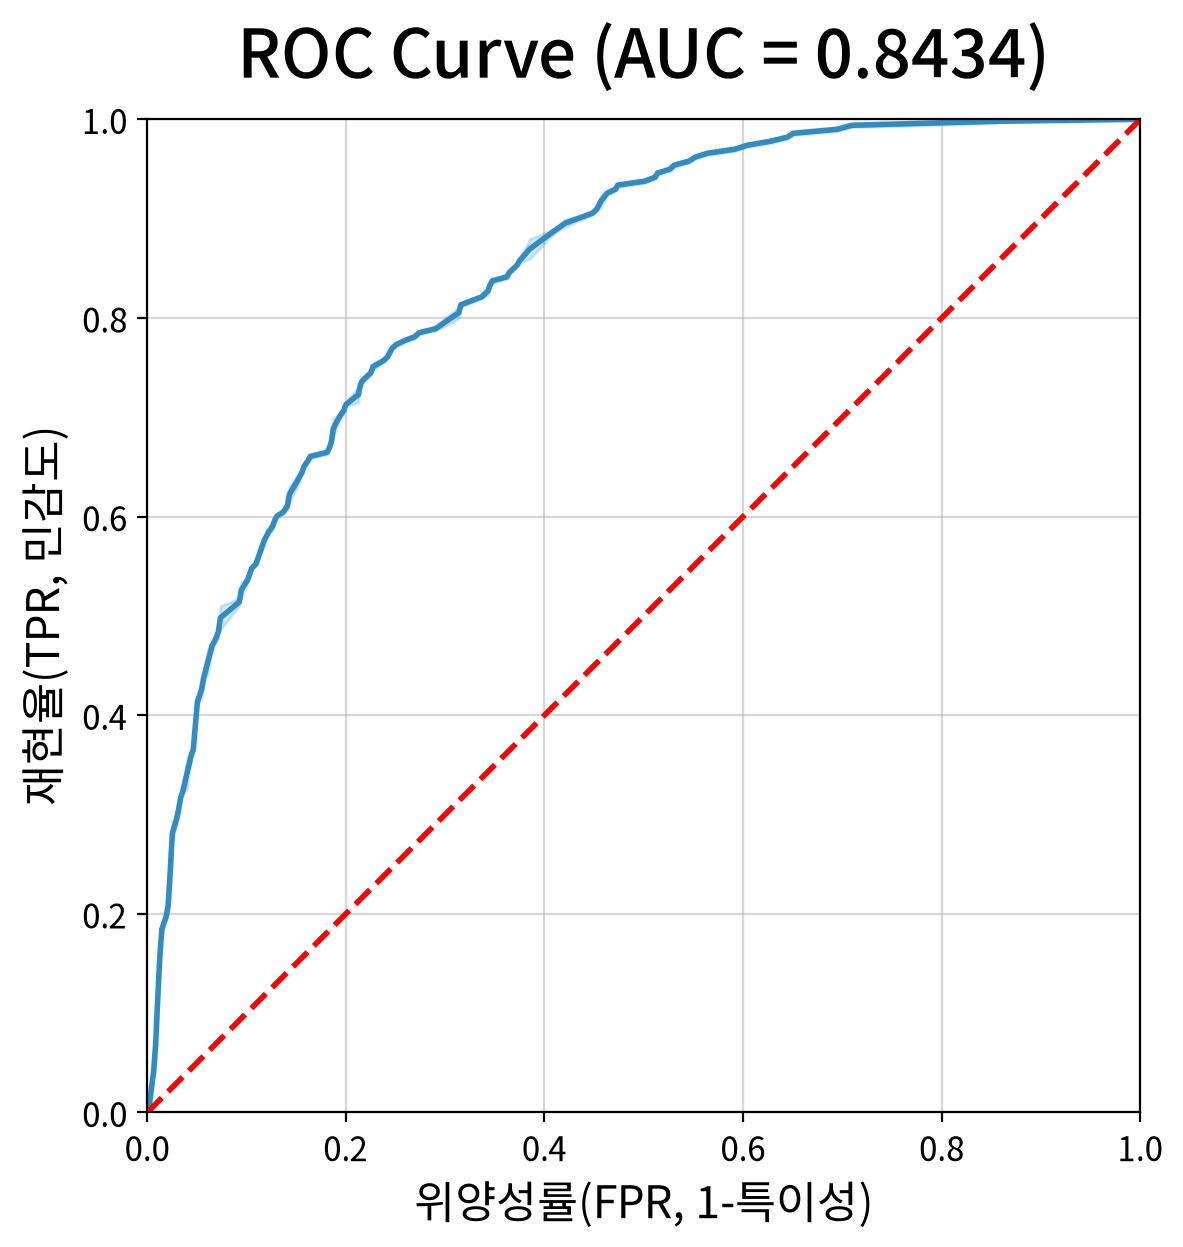

In [33]:
my_logit.plot_roc(fit)

### 3. 분류 성능 평가 

,예측 0 (Negative),예측 1 (Positive)
실제 0 (Negative),420,55
실제 1 (Positive),107,142


,정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성율(Fallout, FPR)","특이성(Specificity, TNR)",F1,AUC,AUC 판단,진단오즈비(DOR)
preformance,0.776,0.721,0.570,0.116,0.884,0.637,0.843,우수,10.134


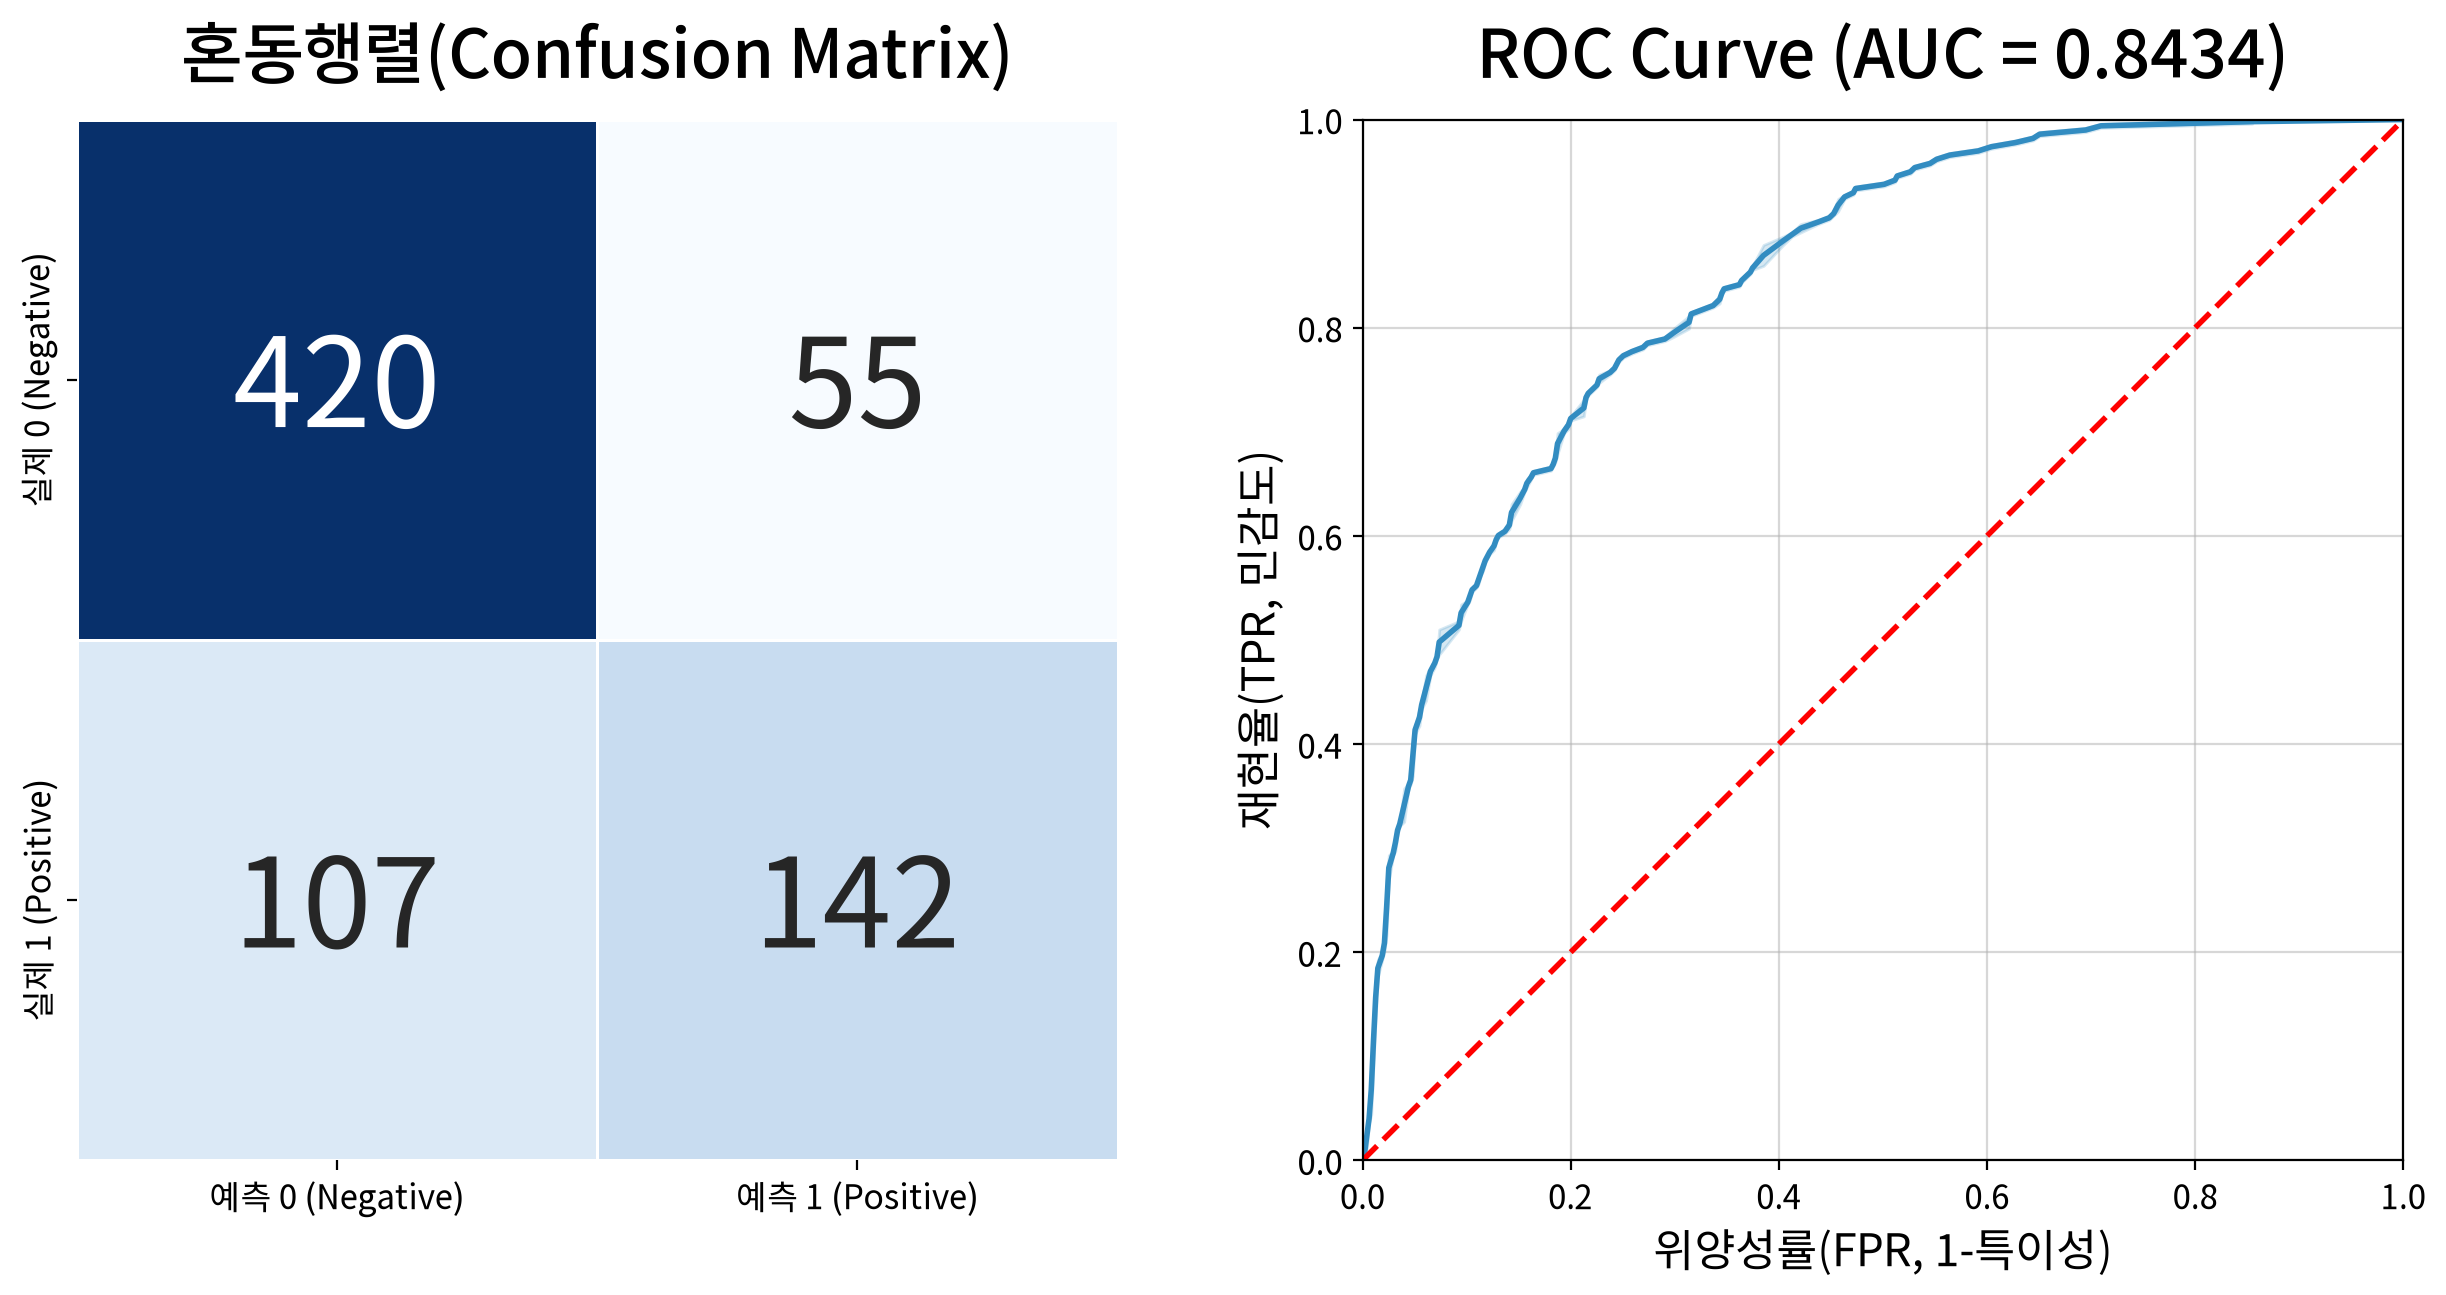

In [34]:
my_logit.report_performance(fit)

## # 연습문제 

In [43]:
from jussam import load_data
from helpers import *
from pandas import DataFrame

import numpy as np

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [35]:
origin = load_data('nursing_grades_preprocessed')
origin.head()

📚 어느 간호학과 대학원에 지원한 학생들에 대한 합격/불합격 여부를 조사한 가상의 데이터에 대한 전처리 완료 버전


,성별,필기점수,학부성적,병원경력,합격여부
0,0,380,3.610,3,0
1,0,660,3.670,3,1
2,0,800,4.000,1,1
3,1,640,3.190,4,1
4,0,520,2.930,4,0


In [45]:
y_real = origin['합격여부']

# 종속변수의 값별 개수와 비율
count = y_real.value_counts()
ratio = y_real.value_counts(normalize=True)
display(DataFrame({"인원수":count, "비율":ratio}))

# 아무것도 계산하지 않고, 무조건 '불합격(0)'이라고만 답하는 모형
y_lazy = np.zeros(len(y_real), dtype=int)
print(f"'무조건 불합격'모형의 정확도: {accuracy_score(y_real, y_lazy ):.3f}")

,인원수,비율
합격여부,,
0,250,0.663
1,127,0.337


'무조건 불합격'모형의 정확도: 0.663


In [ ]:
fit = my_logit.auto_logit(origin, '합격여부', plot=False, report=False)

In [ ]:
y_true = np.asanyarray(fit.model.endog).astype(int) # 실제 당뇨 여부(0/1)
proba = np.asarray(fit.predict()) # 당뇨(1)일 예측 확률


y_pred = (proba>0.5).astype(int) # 임계값 0.5로 이진화 
cm = confusion_matrix(y_true, y_pred) # 혼동행렬 배열

# 네 칸을 TN/ FP / FN / TP 로 분해 (순서가 정해져 있다)
tn, fp, fn, tp = cm.ravel()

print(f"TN(합격인을 합격으로 맞힘): {tn}")
print(f"FP(합격인을 불합격로 헛짚음): {fp}")
print(f"FN(합격인를 놓침): {fn}")
print(f"TP(합격인를 맞힘): {tp}")

,예측 0 (Negative),예측 1 (Positive)
실제 0 (Negative),226,24
실제 1 (Positive),92,35


,정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성율(Fallout, FPR)","특이성(Specificity, TNR)",F1,AUC,AUC 판단,진단오즈비(DOR)
preformance,0.692,0.593,0.276,0.096,0.904,0.376,0.690,낮음,3.582


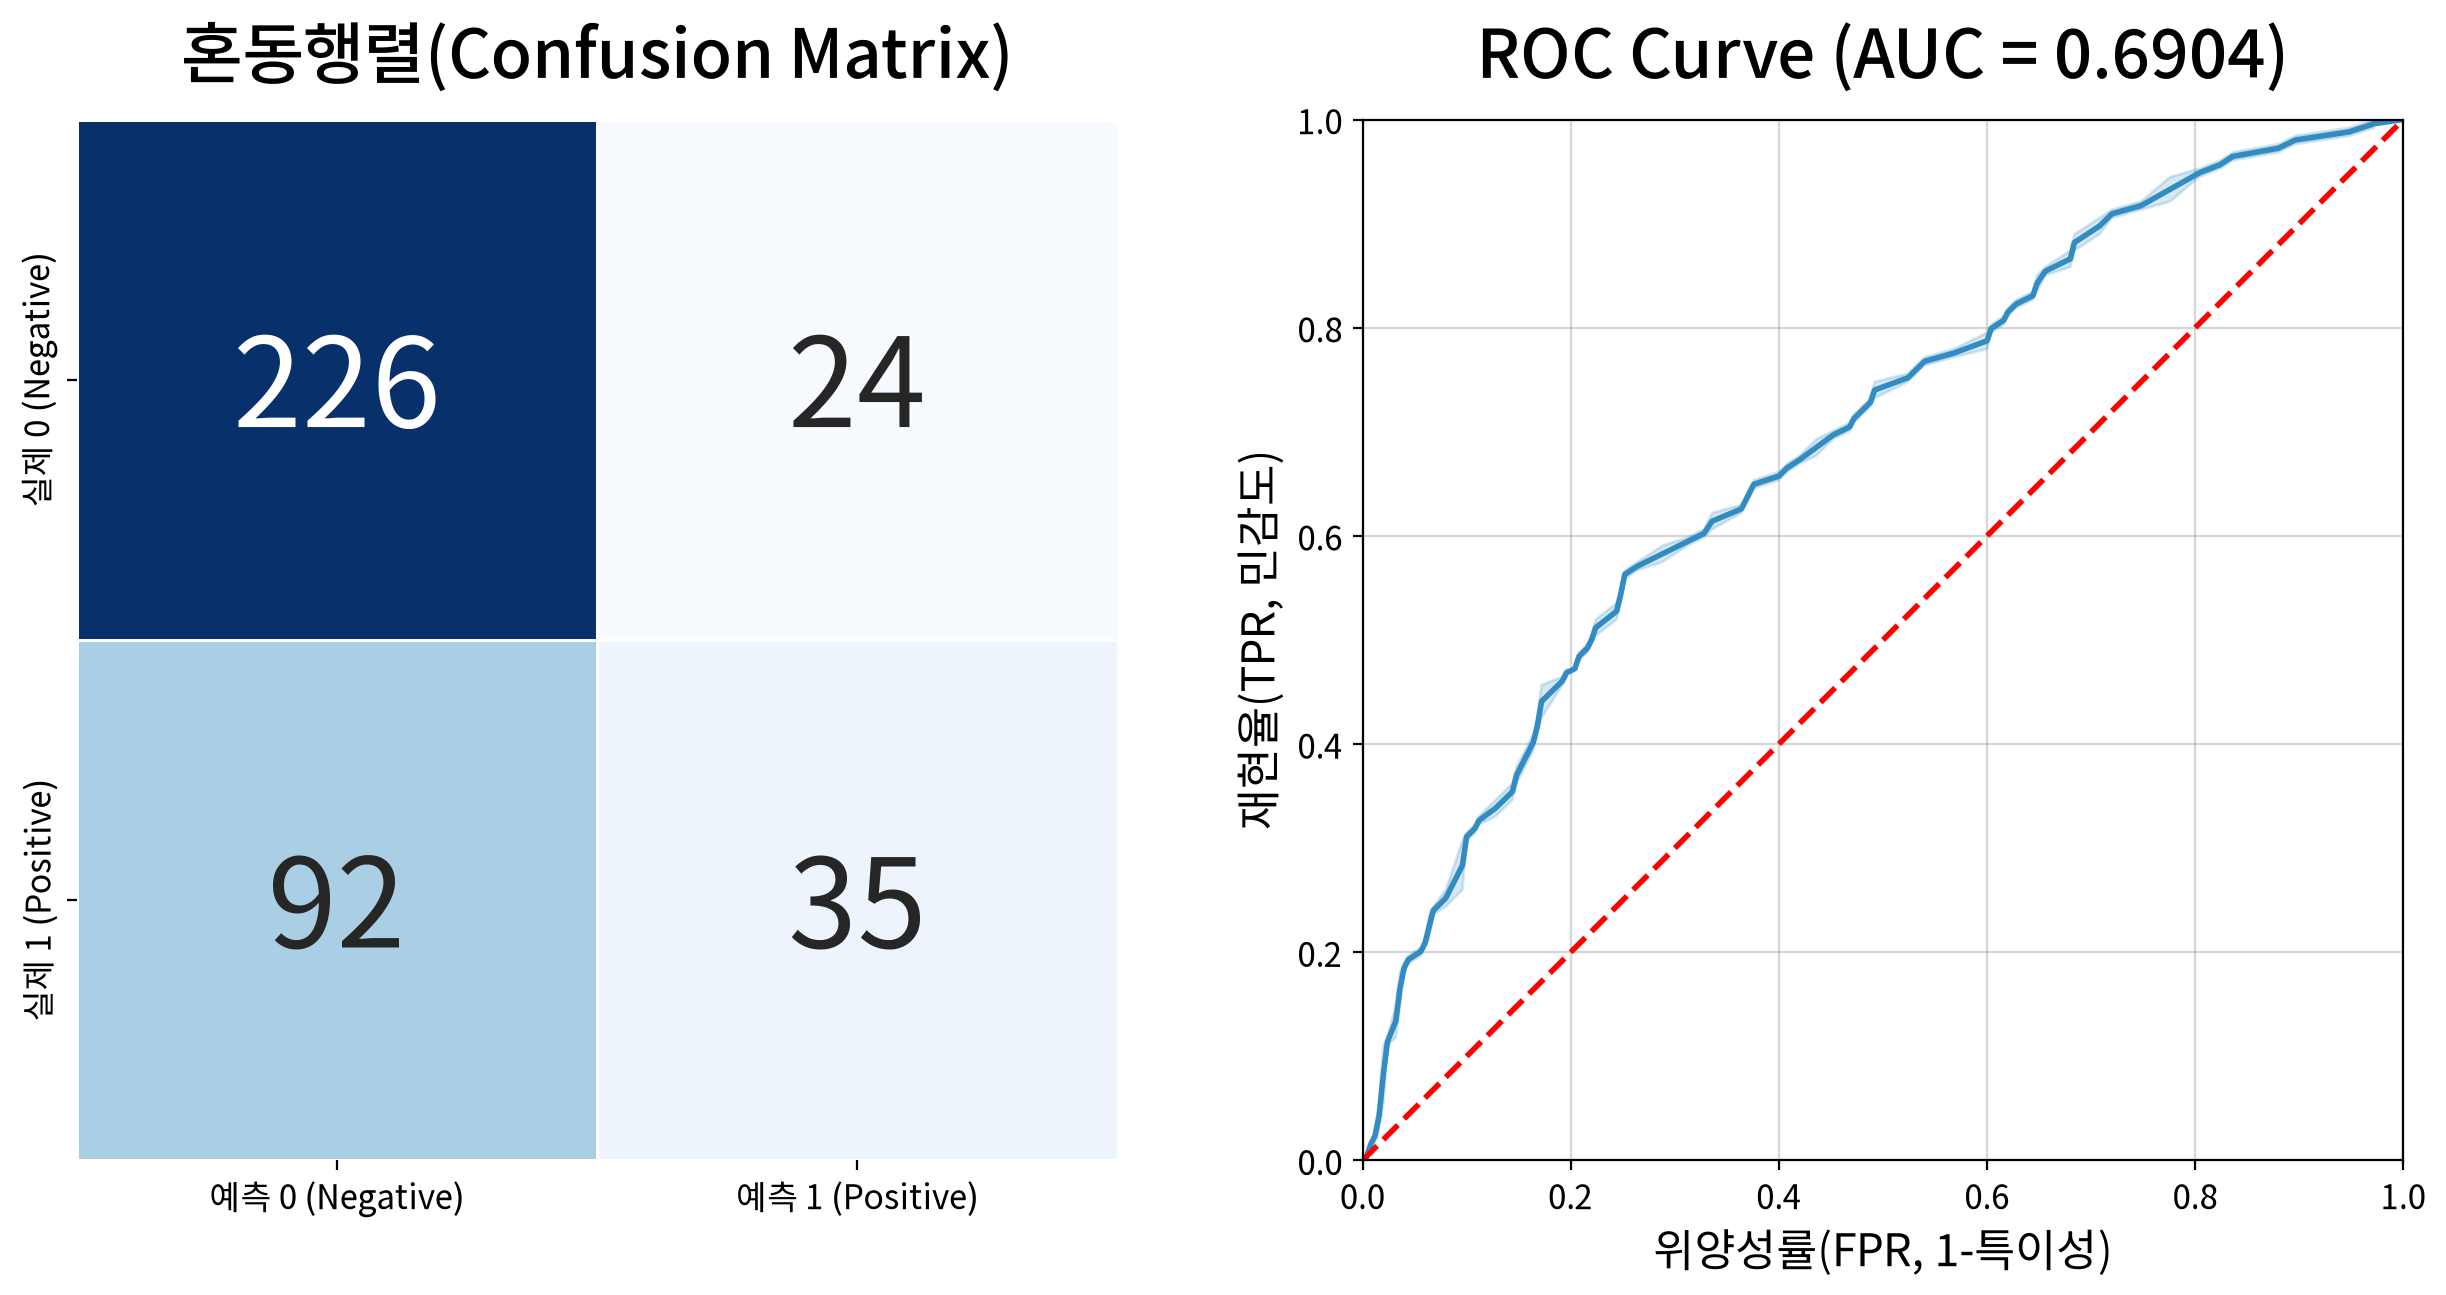

In [41]:
my_logit.report_performance(fit)

In [ ]:
# 지원자 전원 무조건 불합격으로만 찍는 모형의 정확도는 ? 
# 정확도 라는 숫자 하나만 보고 "70%면 쓸만하다"고 말하기 어려움. 
# 전원을 0으로 찍으면 250명을 맞히므로, 0.663
# 0.663
 
# 임계값 0.5에서 실제 합격인데 불합격으로 예측한 지원자
# 혼동행렬의 네 칸 위치를 헷갈려 FP(24)를 답하기 쉬움.
# 행은 실제, 열은 예측이라는 순서를 먼저 확인할 것. 
# 배열로 풀때도, tn, fp, fn, tp 순서가 정해져 있음을 기억하기 
# 92  

# 실제 합격자 가운데 모형이 찾아낸 비율
# 특이성은 0.904로 매우 높음. 불합격자는 잘 걸러내는데, 합격자는 열명 중 세명도 못찾는, 
# 다수 범주 쪽으로 완전히 기울어진 모형. 
# 상담이라는 목적에서 중요한 쪽은 재현율. 어느 지표를 보고 할지는 모형이 아니라 모형을 쓰는 목적이 정함. 
# 재현율 0.276


# 특정 임계값이 아니라 모든 임계값을 통틀어 모형의 실력을 요약하는 지표
# 성능 평가 결과표는 이 지표에 어떤 판단 등급을 붙이는가 
# 0.6904 임으로 0.7에 못미치므로 판정은 낮음. 
# 낮음 

# 모형의 판정과 실제 결과가 얼마나 강하게 연결되어 있는지 혼동행렬 네칸으로 요약한 값은?
# 합격으로 판정된 사람의 실제 합격 오즈가 불합격으로 판정된 사람에 비해 몇배인가 
# 1이면 판정과 실제가 무관하다는 의미 
# 1보다 크므로 판정이 무의미하지는 않지만, 당뇨 데이터에서 본 10.13에 비하면 연결의 강도가 훨씬 약함. 
# 진단오즈비 3.582 

# 정밀도와 재현율을 높아지게 하는 임계값 
# 임계값을 낮추면 양성으로 판정하는 범위가 넓어져 재현율이 오르고, 정밀도가 내려감
# F1은 두지표의 조화평균이라 한쪽만 높아서는 점수를 딸 수 없음. 
# 0.3 

In [42]:
rows = []

for t in [0.3, 0.4, 0.5, 0.6, 0.7]: # 임계값을 0.3~0.7로 바꿔가며 관찰 
    p = (proba>t).astype(int) # 임계값 t로 이진화 
    rows.append({
        "임계값":t, 
        "정확도":accuracy_score(y_true, p), 
        "정밀도":precision_score(y_true, p), 
        "재현율":recall_score(y_true, p), 
        "F1":f1_score(y_true, p), 
        "놓친 환자수(FN)": confusion_matrix(y_true, p).ravel()[2], 
    })

display(DataFrame(rows).round(3))
roc_fpr, roc_tpr, thresholds = roc_curve(y_true, proba)

print(f"계산된 임계값 개수: {len(thresholds)}개")
df = DataFrame({"임계값":thresholds, "FPR":roc_fpr, "TPR(재현율)":roc_tpr})
df.head()

,임계값,정확도,정밀도,재현율,F1,놓친 환자수(FN)
0,0.300,0.586,0.433,0.732,0.544,34
1,0.400,0.690,0.541,0.520,0.530,61
2,0.500,0.692,0.593,0.276,0.376,92
3,0.600,0.682,0.652,0.118,0.200,112
4,0.700,0.660,0.400,0.016,0.030,125


계산된 임계값 개수: 160개


,임계값,FPR,TPR(재현율)
0,inf,0.000,0.000
1,0.744,0.004,0.000
2,0.716,0.004,0.008
3,0.707,0.008,0.016
4,0.704,0.012,0.016


In [ ]:
# 정확도 
# 게으른 모형 
# 임계값 0.5
# AUC 

# -> 현재 변수 네개로는 합격을 설명하기 어려우니, 
# 상담 도입에 앞서 자기소개서 평가나 면접 점수 같은 설명변수를 더 확보해야 함. 